#### **Análisis y Procesamiento de Señales**
# **Trabajo Práctico Nº2 "Modelizando un ADC"**
#### Federico Dunel


## **Introduccion**
En el siguiente trabajo se realizó un algoritmo en python que simula los efectos de un ADC en una señal senoidal contaminada con ruido previamente determinado. Luego se analizó como afecta la digitalización y el ruido agregado al espectro de potencia de la señal.



#### Generación de los parametros del código
Se utilizó la función generadora de senoidales del trabajo anterior, con un valor de frecuencia de muestreo de 1000Hz y con una frecuencia tal que coincida exactamente con los bins de la FFT, siendo sus valores de la forma $f_k = \frac{k f_s}{N}$, por lo tanto la frecuencia es $f = \frac{f_s}{N}$ o un multiplo entero de la misma. De esta forma se podrá apreciar el punto máximo de la PSD exactamente en un bin. Luego se determinaron los valores para simular la digitalización, siendo **Vf** el rango analogico del ADC, **B** la cantidad de bits, **q** el salto de cuantización. La potencia del ruido de cuantización esta dada por $Pq = \frac{q^2}{12}$. Este valor multiplicado por un factor **k** será el que utilicemos para definir la Potencia o varianza del ruido agregado a la señal, de distribución normal y media igual a cero.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fft

pi = np.pi
N = 1000
fs = 1000
nn = np.arange(0, N, 1)
tt = nn / fs
amp = np.sqrt(2)

# Parámetros de cuantización
Vf = 2
B = 4
q = 2 * Vf / (2**B)

# Ruido
Pq = (q**2) / 12
k = 1
Pr = k * Pq
n = np.random.normal(0, np.sqrt(Pr), N)

def sen(nn, fs, amp=1, ff=1, ph=0):
    tt = nn / fs
    return amp * np.sin(2 * np.pi * ff * tt + ph)

# Señales
s = sen(nn, fs=fs, amp=2, ff=fs/N, ph=0)
Sr = s + n
Sq = np.round(Sr / q) * q

# Error de cuantización
e_q = Sr - Sq
e_q = e_q - np.mean(e_q)

# Densidades epectrales de potencia

SQ = (1/N) * fft.fft(Sq)
PSD_Sq = np.abs(SQ)**2
SQdb = 10 * np.log10(PSD_Sq + 1e-12)

NR = (1/N) * fft.fft(n)
PSD_n = np.abs(NR)**2
NRdb = 10 * np.log10(PSD_n + 1e-12)

EQ = (1/N) * fft.fft(e_q)
PSD_eq = np.abs(EQ)**2
EQdb = 10 * np.log10(PSD_eq + 1e-12)

#Eje de frecuencias

f = np.arange(0, N) * fs / N

## Gráfico de resultados
1. **Señal senoidal con ruido**

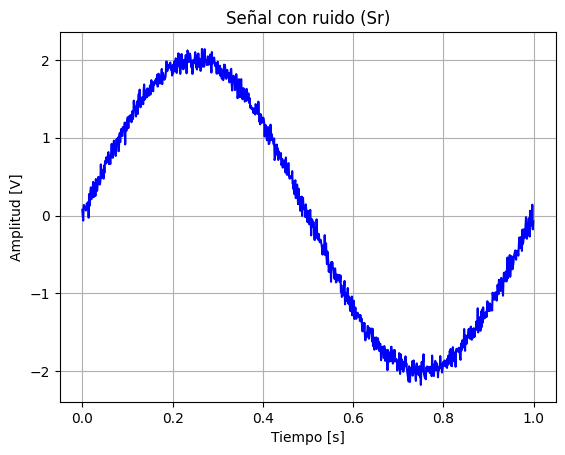

In [9]:
plt.figure()
plt.plot(tt, Sr, color='blue')
plt.title("Señal con ruido (Sr)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.show()

Esta señal fue generada con un valor de k = 1, teniendo el ruido agregado la misma potencia que el de cuantización. Para que se puedan visualizar todos los pasos de cuantización del ADC se le dió una amplitud de 2V

2. **Señal cuantizada a traves del ADC simulado**

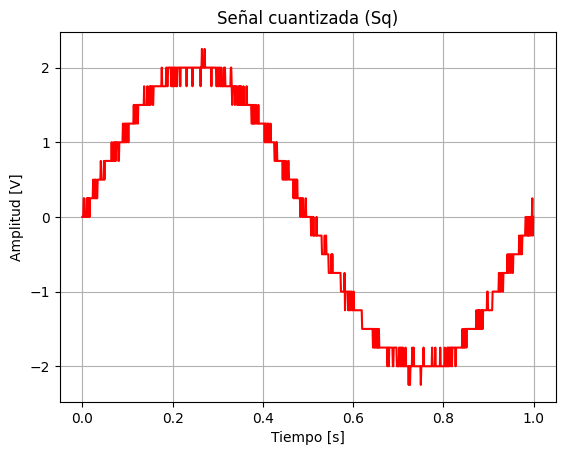

In [10]:
plt.figure()
plt.plot(tt, Sq, color='red')
plt.title("Señal cuantizada (Sq)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()
plt.show()

3. **Histograma del ruido de cuantización**

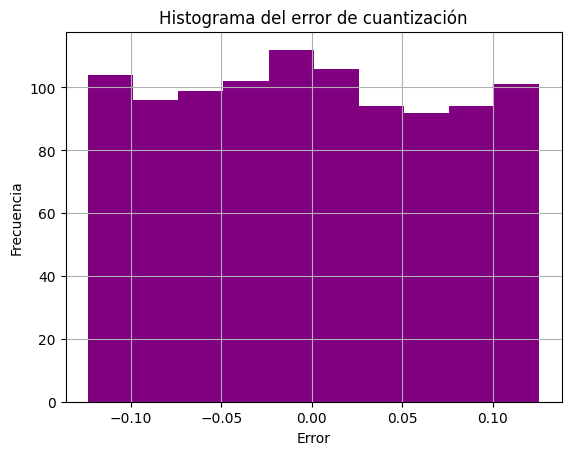

In [17]:
plt.figure()
plt.hist(e_q, bins=10, color='purple')
plt.title("Histograma del error de cuantización")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.grid()

plt.show()

Habiendo previamiente definido el error de la cuantización como la diferencia entre la señal cuantizada y la original podemos apreciar que a traves de 10 bins hay alrededor de 100 muestras. Esto de un total de 1000 se aproxima a una distribución uniforme.

4. **Densidades espectrales de potencia (PSD)**

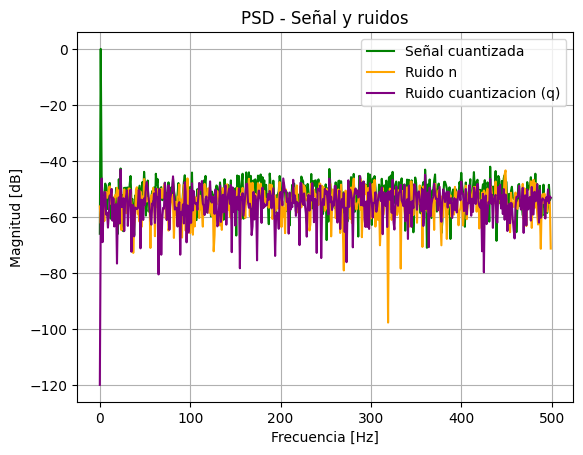

In [18]:
plt.figure()
plt.plot(f[:N//2], SQdb[:N//2], label='Señal cuantizada', color='green')
plt.plot(f[:N//2], NRdb[:N//2], label='Ruido n', color='orange')
plt.plot(f[:N//2], EQdb[:N//2], label='Ruido cuantizacion (q)', color='purple')

plt.title("PSD - Señal y ruidos")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.legend()
plt.grid()

plt.show()

Se puede apreciar como casi la totalidad de la energía de la señal se encuentra en el primer bin. Luego en el resto del gráfico se puede ver como se distribuye el resto a traves de la otra parte del espectro positivo. También se puede observar como el piso de la PSD de la señal (que cuenta con la energía de ambos ruidos sumados) corresponde con los pisos de los ruidos que al tener la misma potencia oscilan alrededor del mismo valor. Es importante destacar que el piso de este gráfico no corresponde con la relación señal a ruido del SNR, ya que las PSD muestran la distribución de esta energía en todo el espectro muestreado, por lo que depende también del numero de muestras (N) y de la frecuencia de muestreo (fs).

#### Análisis de la señal variando K=10 y B=8
Se cambiaron los parametros del ADC a uno de 8 bits, también se cambió la relación entre el ruido gaussiano y el de cuantización. Volvemos a definir las variables pero con estos valores diferentes.

In [19]:
pi = np.pi
N = 1000
fs = 1000
nn = np.arange(0, N, 1)
tt = nn / fs
amp = np.sqrt(2)

# Parámetros de cuantización
Vf = 2
B = 8
q =  2 * Vf / (2**B)

# Ruido
Pq = (q**2) / 12
k = 10
Pr = k * Pq
n = np.random.normal(0, np.sqrt(Pr), N)

def sen(nn, fs, amp = 1, ff=1, ph=0):
    tt = nn / fs
    return amp * np.sin(2 * np.pi * ff * tt + ph)

# Señales
s = sen(nn, fs=fs, amp=2, ff=fs/N, ph=0)
Sr = s + n
Sq = np.round(Sr / q) * q

# Error de cuantización
e_q = Sr - Sq
e_q = e_q - np.mean(e_q)

# Densidades epectrales de potencia

SQ = (1/N) * fft.fft(Sq)
PSD_Sq = np.abs(SQ)**2
SQdb = 10 * np.log10(PSD_Sq + 1e-12)

NR = (1/N) * fft.fft(n)
PSD_n = np.abs(NR)**2
NRdb = 10 * np.log10(PSD_n + 1e-12)

EQ = (1/N) * fft.fft(e_q)
PSD_eq = np.abs(EQ)**2
EQdb = 10 * np.log10(PSD_eq + 1e-12)


6. **Gráfico de las señales sin cuantizar y cuantizada**

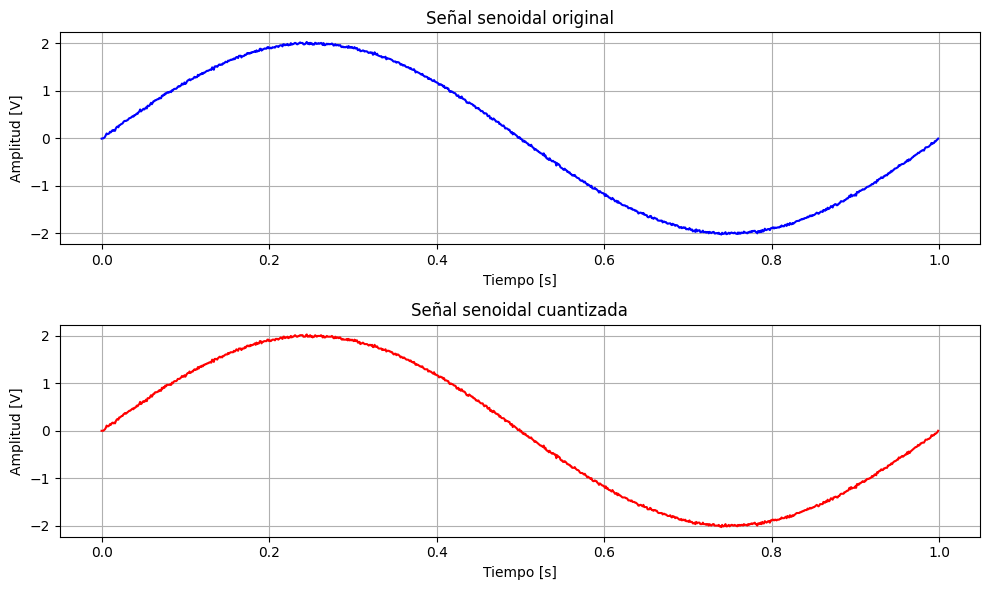

In [20]:
plt.figure(figsize=(10,6))

# 1. Señal original
plt.subplot(2,1,1)
plt.plot(tt, Sr, color='blue')
plt.title("Señal senoidal original")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()

# 2. Señal cuantizada
plt.subplot(2,1,2)
plt.plot(tt, Sq, color='red')
plt.title("Señal senoidal cuantizada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid()

plt.xlim(0, 0.05)
plt.tight_layout()
plt.show()

A simple vista no se puede apreciar ninguna diferencia, esto se debe a que el salto de cuantización disminuye de manera exponencial con la cantidad de bits. En este caso $\frac{2V_f}{2^8} = \frac{4}{256} = 0.0156$, lo cuál es un valor tan pequeño que la diferencia con la señal original no es visible

7. **Histograma del error de cuantización**

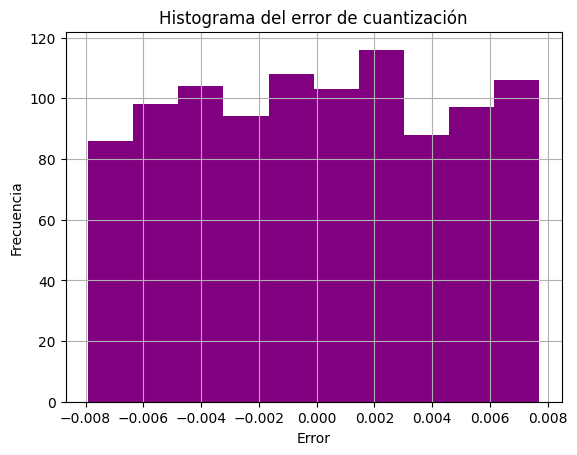

In [25]:
plt.figure()
plt.hist(e_q, bins=10, color='purple')
plt.title("Histograma del error de cuantización")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.grid()

plt.show()

Se puede apreciar entonces como los valores posibles del error son ahora mucho más pequeños y cercanos a 0, esto corresponde con la relación teorica que hicimos donde su varianza o potencia corresponde a la ecuación $P_q = \frac{q^2}{12}$. Entonces al reducirse tanto q también reduce enormemente su potencia.

8. **Densidades de potencia espectral**

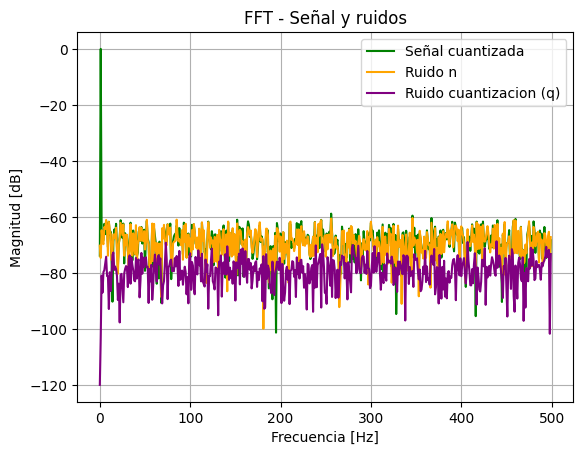

In [26]:
plt.figure()
plt.plot(f[:N//2], SQdb[:N//2], label='Señal cuantizada', color='green')
plt.plot(f[:N//2], NRdb[:N//2], label='Ruido n', color='orange')
plt.plot(f[:N//2], EQdb[:N//2], label='Ruido cuantizacion (q)', color='purple')

plt.title("FFT - Señal y ruidos")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.legend()
plt.grid()

plt.show()

En este último gráfico se puede ver la gran disminución de la densidad de potencia del ruido, cayendo por debajo de -60db. También como predomina el ruido gaussiano por encima del de cuantización por casi 10db (es 10 veces mayor gracias al factor k=10), determinando el piso de la PSD. Esto también explica que en la señal sea casi imperseptible el efecto del ADC.
Esto se explica debido a que el aumento considerable del numero de Bits disminuye de forma exponencial el tamaño de los saltos de cuantización. Esto hace que la diferencia entre la señal cuantizada y la original se reduzca enormemente, en los gráficos esto puede apreciarse en los valores del histograma del error de cuantización, que se volvieron mucho más cercanos a 0 con el aumento de **B**.Esto altera el SNR ya que disminuye considerablemente la varianza o potencia del ruido de cuantización, esto en ausencia de un ruido que acarree la señal antes de entrar al ADC deja un piso de ruido muy bajo. Sino lo que termina ocurriendo es que el SNR depende principalmente de la potencia del ruido de la señal sin cuantizar.